# ⚡ Predicción de la Demanda Eléctrica de Texas (ERCOT): Pronóstico a 24 Horas

### 📊 Resumen Ejecutivo: Modelo Predictivo de Carga de la Red

* **Contexto:** ERCOT (*Electric Reliability Council of Texas*) opera la red eléctrica que abastece a la mayor parte de la carga de Texas. Anticipar la demanda horaria es crítico para el despacho de generación, la estabilidad de la red y la prevención de apagones como los de la tormenta invernal Uri (2021). Este proyecto construye el motor predictivo que alimenta un dashboard ejecutivo de MLOps en tiempo real (`app.py`).

* **Objetivo Estratégico:** Construir un modelo de regresión capaz de pronosticar la demanda eléctrica (`value`, en MW) de las **próximas 24 horas**, combinando el historial de carga de la red con variables meteorológicas de las tres principales ciudades de Texas (Houston, Dallas y Austin), priorizando **precisión** (MAPE bajo), **robustez temporal** y **velocidad de reentrenamiento**.

* **Fuentes de Datos:**
    1. 🔌 **Demanda (API de la EIA):** Serie horaria de carga de ERCOT 2022–2025, extraída en `EIA_API.ipynb`.
    2. 🌡️ **Clima (API de Open-Meteo):** Temperatura, humedad, sensación térmica y velocidad del viento por hora para Houston, Dallas y Austin, extraída en `OPEN_METEO_API.ipynb`.

* **Metodología y Flujo de Trabajo:**
    1. 📥 **Unificación:** Fusión horaria de demanda y clima sobre la marca temporal en UTC.
    2. 🧹 **Limpieza:** Normalización de nombres, descarte de metadatos del API e indexado temporal.
    3. 📈 **EDA:** Análisis de correlaciones y de la relación no lineal (curva en U) entre temperatura y carga.
    4. 🛠️ **Ingeniería de Características:** Variables de calendario, retrasos estacionales (*lags*), ventanas móviles, feriados, grados-día (HDD/CDD) y deltas térmicos.
    5. 🤖 **Modelado:** Comparativa XGBoost vs. LightGBM bajo validación cruzada temporal (`TimeSeriesSplit`) y optimización con `RandomizedSearchCV`.
    6. 🚀 **Producción:** Reentrenamiento sobre el 100% de los datos y serialización del modelo para el dashboard.

* **Resultados Clave:**

    - **Modelo seleccionado:** **LightGBM optimizado**, con un **MAPE de 3.11%** sobre el año de prueba ciego 2025 (≈ 1,735 MW de error medio horario sobre una demanda media cercana a los 55,000 MW).
    - **Driver dominante:** El **delta térmico de 24h** (`temp_delta_24h`) y el **historial de carga del día anterior** (`load_lag_24`) son los predictores más influyentes, confirmando que la demanda se rige por la inercia de la red y los frentes climáticos.
    - **Validación robusta:** La partición estrictamente cronológica (entrenar en 2022–2024, probar en 2025) garantiza que no exista fuga temporal de información.

    | Etapa del Modelo | MAPE (Test 2025) | Mejora |
    |---|---|---|
    | 1️⃣ Baseline XGBoost (lags + ventanas) | 3.78% | — |
    | 2️⃣ + Ingeniería Avanzada (feriados, HDD/CDD, deltas) | 3.17% | ⬇️ 0.61 pts |
    | 🥇 **LightGBM Optimizado (final)** | **3.11%** | ⬇️ 0.67 pts |

> 💡 **Nota:** El conjunto de prueba (año 2025) permanece completamente aislado durante todo el entrenamiento y la optimización; las métricas reportadas corresponden a inferencia sobre datos nunca vistos.

---

**Tabla de Contenidos**

1. Configuración del Entorno e Importación de Librerías
2. Adquisición y Unificación de Datos
3. Análisis Exploratorio de Datos (EDA)
4. Ingeniería de Características
5. Modelado Base y Partición Temporal (XGBoost)
6. Ingeniería de Características Avanzada
7. Validación Cruzada Temporal (XGBoost vs. LightGBM)
8. Optimización de Hiperparámetros
9. Modelo de Producción y Serialización
10. Conclusiones y Recomendación Final

### 1. 🛠️ Configuración del Entorno e Importación de Librerías

Cargamos el ecosistema de herramientas necesario para el proyecto:

* **Manipulación y cálculo:** `pandas` y `numpy`.
* **Visualización:** `matplotlib` y `seaborn` (con estilo de fondo oscuro, coherente con el dashboard ejecutivo).
* **Modelado:** `XGBRegressor` y `LGBMRegressor`, los dos algoritmos de *Gradient Boosting* que competirán por el despliegue.
* **Validación temporal:** `TimeSeriesSplit` para respetar el orden cronológico de los pliegues y `RandomizedSearchCV` para la búsqueda de hiperparámetros.

La opción `pd.set_option('display.max_columns', None)` garantiza la visibilidad completa de las columnas durante la auditoría de datos.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import shap
pd.set_option('display.max_columns', None)
plt.style.use('dark_background')

### 2. 📥 Adquisición y Unificación de Datos

El proyecto integra dos fuentes de datos horarias independientes, ambas extraídas previamente y persistidas como CSV estáticos para garantizar la reproducibilidad del análisis:

* **`ercot_load_2022_2025_static.csv`** — Demanda real de la red ERCOT obtenida vía la **API de la EIA** (ver `EIA_API.ipynb`). La columna `value` (en MW) es nuestra **variable objetivo**.
* **`texas_weather_2022_2025_static.csv`** — Variables meteorológicas horarias de Houston, Dallas y Austin obtenidas vía la **API de Open-Meteo** (ver `OPEN_METEO_API.ipynb`).

Ambos archivos se cargan parseando explícitamente sus columnas temporales (`period` y `timestamp_utc`) como objetos `datetime`, requisito indispensable para el alineamiento horario posterior.

In [2]:
df_electricity = pd.read_csv('../data/ercot_load_2022_2025_static.csv', parse_dates=['period'])
df_weather = pd.read_csv('../data/texas_weather_2022_2025_static.csv', parse_dates=['timestamp_utc'])

Unificamos ambas matrices con un `merge` interno (`how='inner'`) usando como llave la marca temporal: `period` (demanda) contra `timestamp_utc` (clima). El *inner join* asegura que solo conservemos las horas en las que **tanto la demanda como el clima** están disponibles, evitando filas huérfanas que introducirían valores nulos.

In [3]:
df_full = pd.merge(df_electricity, df_weather, left_on='period', right_on='timestamp_utc', how='inner')

In [4]:
df_full.info()

<class 'pandas.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   period                 35064 non-null  datetime64[us]
 1   respondent             35064 non-null  str           
 2   respondent-name        35064 non-null  str           
 3   type                   35064 non-null  str           
 4   type-name              35064 non-null  str           
 5   value                  35064 non-null  int64         
 6   value-units            35064 non-null  str           
 7   timestamp_utc          35064 non-null  datetime64[us]
 8   Houston_temp           35064 non-null  float64       
 9   Houston_humidity       35064 non-null  int64         
 10  Houston_apparent_temp  35064 non-null  float64       
 11  Houston_wind_speed     35064 non-null  float64       
 12  Dallas_temp            35064 non-null  float64       
 13  Dallas_humid

**📌 Diagnóstico estructural:** El dataset unificado contiene **35,064 registros horarios** (exactamente 4 años completos: 2022–2025) y **21 columnas**, **sin un solo valor nulo**. La integridad horaria es perfecta, lo que confirma que ambas APIs cubrieron el rango temporal sin huecos.

A continuación **normalizamos los nombres de columnas** a `snake_case` (reemplazando guiones por guiones bajos y pasando todo a minúsculas) para una manipulación consistente a lo largo del proyecto.

In [5]:
df_full.columns = df_full.columns.str.replace('-', '_').str.lower()
df_full.columns.to_list()

['period',
 'respondent',
 'respondent_name',
 'type',
 'type_name',
 'value',
 'value_units',
 'timestamp_utc',
 'houston_temp',
 'houston_humidity',
 'houston_apparent_temp',
 'houston_wind_speed',
 'dallas_temp',
 'dallas_humidity',
 'dallas_apparent_temp',
 'dallas_wind_speed',
 'austin_temp',
 'austin_humidity',
 'austin_apparent_temp',
 'austin_wind_speed',
 'texas_avg_temp']

#### 🗑️ Filtrado de Columnas Redundantes

Varias columnas provienen de los metadatos del API de la EIA y son **constantes o redundantes** para el modelado: el identificador del operador (`respondent`, `respondent_name`), el tipo de serie (`type`, `type_name`), las unidades (`value_units`) y la marca temporal duplicada del clima (`timestamp_utc`). Las descartamos para quedarnos únicamente con la señal predictiva.

In [6]:
cols_to_drop = ['respondent', 'respondent_name', 'type', 'type_name', 'value_units', 'timestamp_utc']
df_clean = df_full.drop(columns=cols_to_drop)

Establecemos `period` como **índice temporal** (`DatetimeIndex`). Este paso es fundamental en series de tiempo: habilita el remuestreo, la extracción de componentes de calendario y, sobre todo, el cálculo correcto de retrasos (*lags*) y ventanas móviles respetando el orden cronológico.

In [7]:
df_clean = df_clean.set_index('period')

### 3. 📈 Análisis Exploratorio de Datos (EDA)

Antes de modelar, exploramos las relaciones entre las variables climáticas y la demanda. Comenzamos con un `pairplot` que ofrece una vista panorámica de las distribuciones marginales y de las relaciones bivariadas de todo el conjunto.

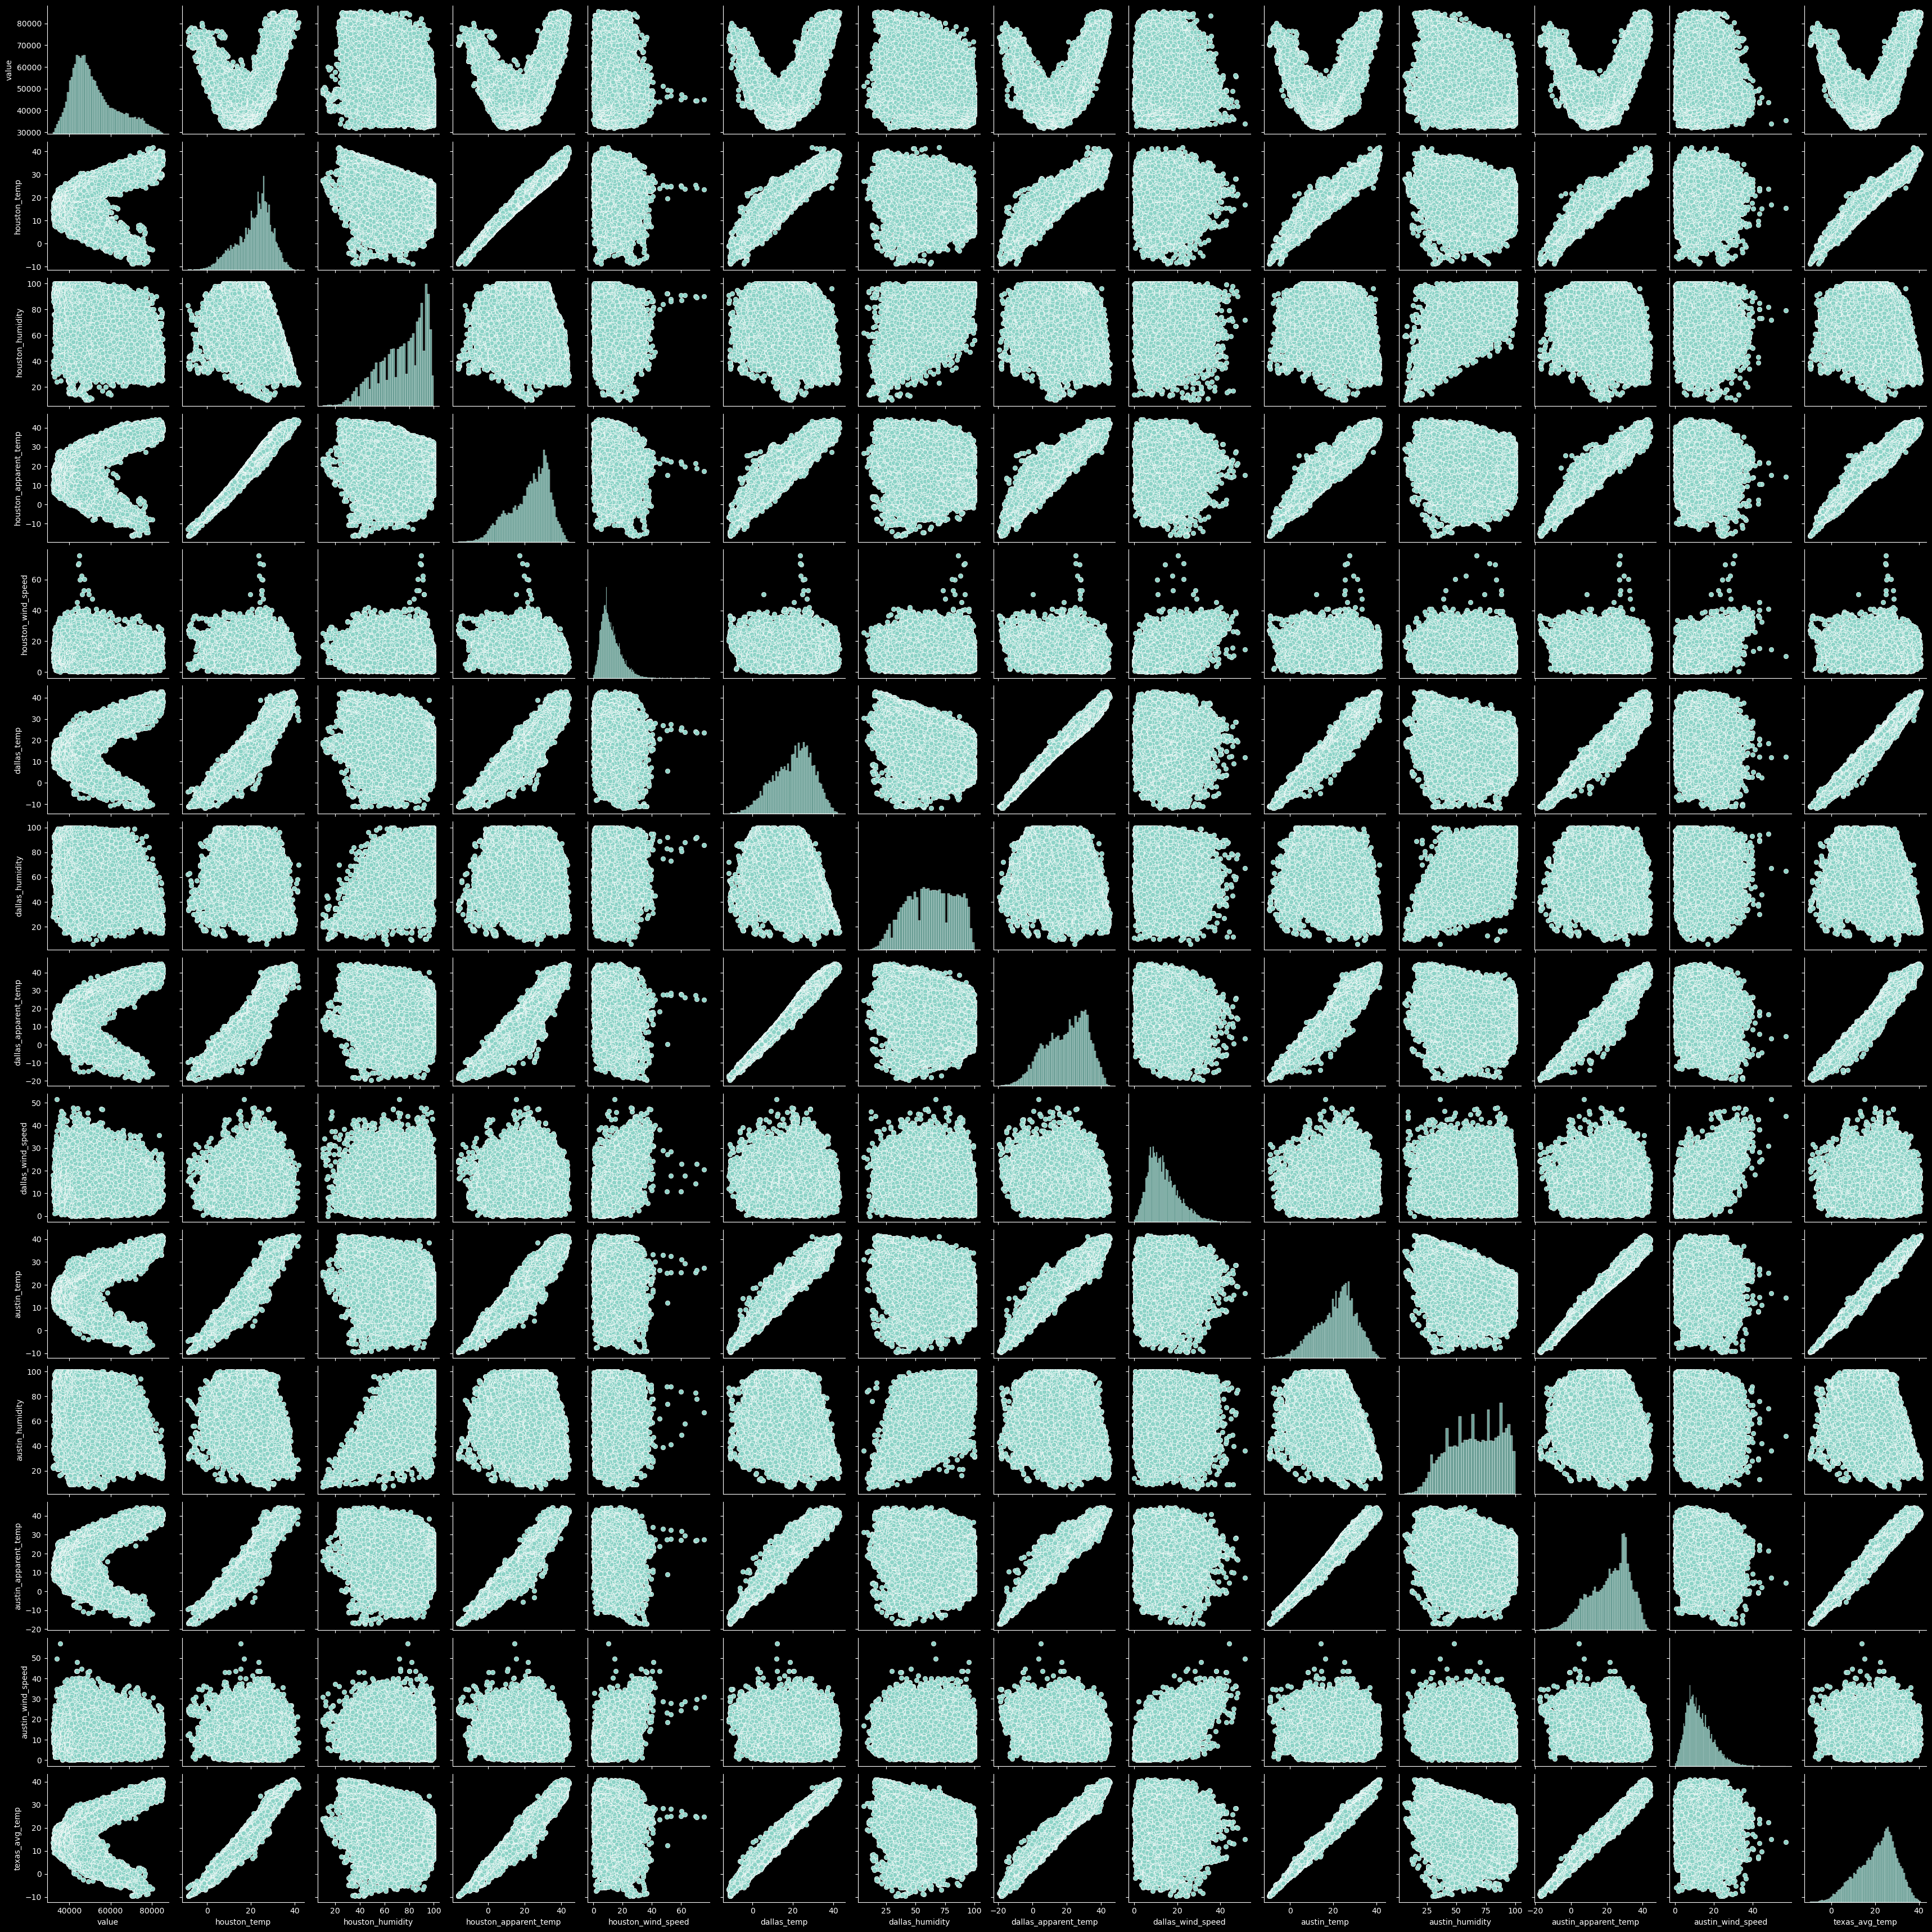

In [8]:
sns.pairplot(df_clean)

El `pairplot` revela distribuciones razonables y la primera pista de que la relación entre clima y demanda **no es estrictamente lineal**. Para cuantificar la fuerza de estas relaciones, calculamos la **matriz de correlación de Pearson** y la visualizamos como un mapa de calor.

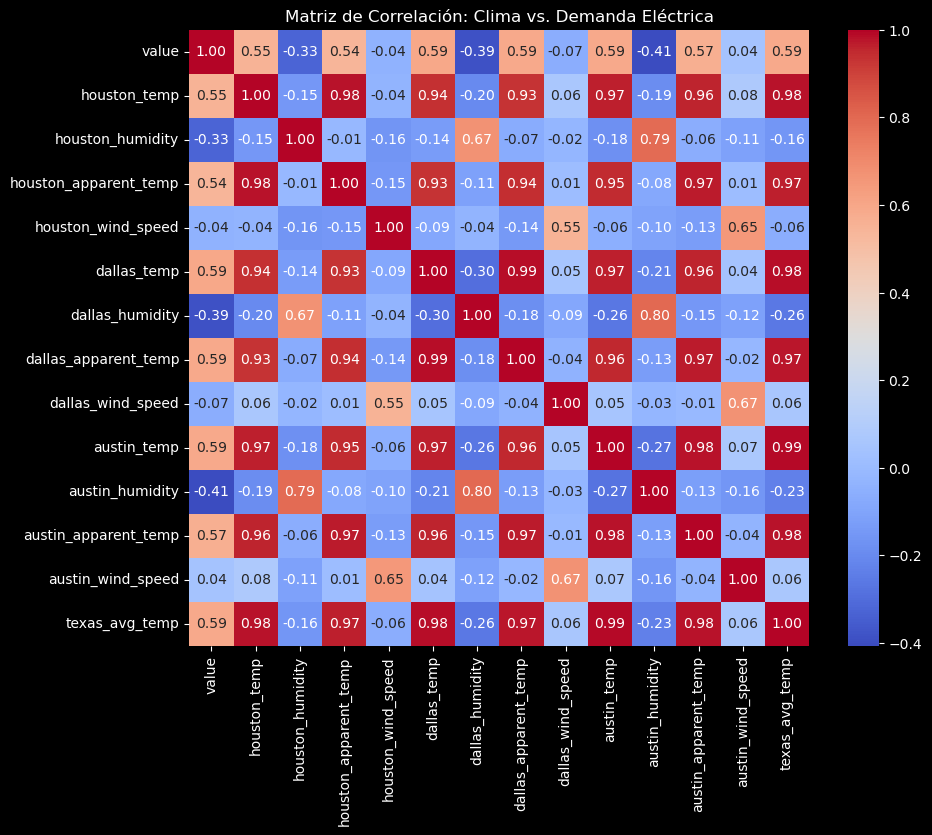

In [9]:
# Calcular correlación solo de las variables de temperatura y el target
temp_cols = [c for c in df_clean.columns if 'temp' in c or c == 'value']
corr_matrix = df_clean[temp_cols].corr()
corr_matrix = df_clean.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlación: Clima vs. Demanda Eléctrica")
plt.show()

**📌 Lectura de la matriz de correlación:** Las temperaturas de las tres ciudades están **fuertemente correlacionadas entre sí** (comparten el mismo régimen climático estatal), por lo que aportan información parcialmente redundante. La correlación lineal de la temperatura con la demanda es solo moderada — precisamente porque la relación real tiene **forma de U** (tanto el frío como el calor disparan el consumo), un patrón que el coeficiente de Pearson subestima por naturaleza. Lo verificamos a continuación con un diagrama de dispersión directo.

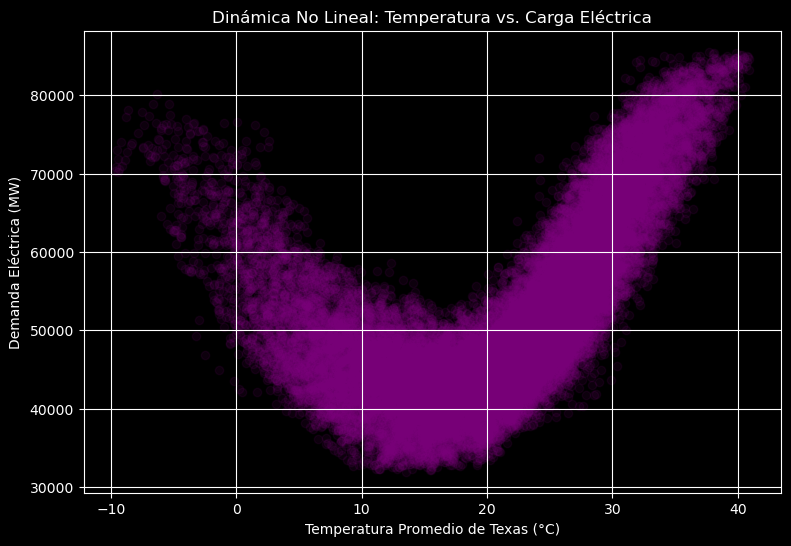

In [10]:
plt.figure(figsize=(9, 6))
plt.scatter(df_clean['texas_avg_temp'], df_clean['value'], alpha=0.1, color='purple')
plt.xlabel('Temperatura Promedio de Texas (°C)')
plt.ylabel('Demanda Eléctrica (MW)')
plt.title('Dinámica No Lineal: Temperatura vs. Carga Eléctrica')
plt.grid(True)
plt.show()

**📌 La dinámica no lineal en forma de U:** El diagrama de dispersión confirma el hallazgo clave del EDA: existe una **relación no lineal en forma de U** entre la temperatura y la carga eléctrica. La demanda alcanza su **mínimo en la zona de confort térmico** (~18 °C) y se dispara en ambos extremos:

* 🥶 **Frío extremo:** Repunte por calefacción eléctrica.
* 🥵 **Calor extremo:** Repunte aún más pronunciado por el aire acondicionado (HVAC), el principal driver de los picos de demanda en Texas.

Esta no linealidad **justifica el uso de modelos basados en árboles** (*Gradient Boosting*) en lugar de una regresión lineal, ya que capturan estos quiebres de forma nativa sin necesidad de transformaciones manuales.

### 4. 🛠️ Ingeniería de Características

La capacidad predictiva de un modelo de series temporales depende casi por completo de la calidad de sus características. Construimos varias familias de variables.

#### 4.1 🗓️ Variables de Calendario

Extraemos del índice temporal la **hora del día**, el **día de la semana**, el **mes** y una bandera de **fin de semana**. Estas variables permiten al modelo aprender los ritmos humanos de consumo (rutina laboral, ocio, estacionalidad anual). Tras crearlas, visualizamos el **perfil horario promedio** de la demanda para validar que el patrón cíclico exista.

In [11]:
df_clean['hour'] = df_clean.index.hour
df_clean['day_of_week'] = df_clean.index.dayofweek  # 0=Lunes, 6=Domingo
df_clean['month'] = df_clean.index.month
df_clean['is_weekend'] = df_clean['day_of_week'].isin([5, 6]).astype(int)

<Axes: xlabel='hour'>

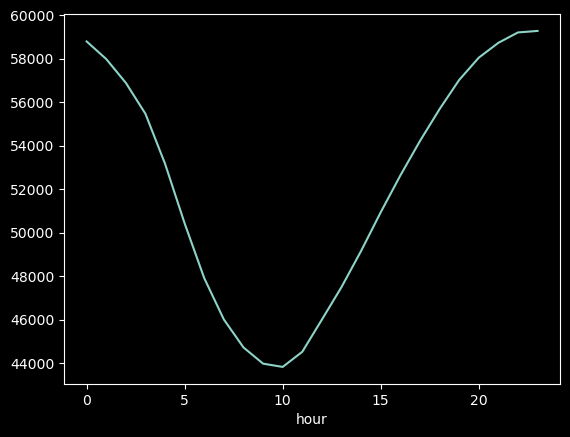

In [12]:
df_clean.groupby('hour')['value'].mean().plot()

**📌 El pulso diario de la red:** El perfil horario promedio exhibe la firma clásica del consumo eléctrico: un valle nocturno de madrugada, una subida matinal y un **pico vespertino** (cuando coinciden el regreso al hogar y la mayor carga de climatización). Este patrón cíclico es altamente predecible y de enorme valor para el modelo.

#### 4.2 ⏳ Retrasos Estacionales (*Lags*) y Ventanas Móviles

Incorporamos la **memoria histórica** de la red. Dado que el dashboard pronostica con **24 horas de anticipación**, no podemos usar la demanda de la hora inmediatamente anterior: toda la información histórica se desplaza al menos 24 horas (`shift(24)`) para evitar la **fuga de datos del futuro** (*data leakage*).

* **Lags:** carga de hace 24h, 48h y 168h (una semana exacta, que captura la rutina semanal).
* **Ventanas móviles:** media, desviación estándar y máximo de las 24h previas, calculadas desde el cierre del día anterior.

In [13]:
# Nos aseguramos de que el dataset esté perfectamente ordenado cronológicamente
df_clean = df_clean.sort_index()

# =====================================================================
# 1. RETRASOS ESTACIONALES (Lags)
# =====================================================================
# ¿Qué pasó ayer a esta misma hora? (Hace 24 horas)
df_clean['load_lag_24'] = df_clean['value'].shift(24)

# ¿Qué pasó hace dos días a esta misma hora? (Hace 48 horas)
df_clean['load_lag_48'] = df_clean['value'].shift(48)

# ¿Qué pasó la semana pasada a esta misma hora? (Hace 168 horas)
# Este es un predictor brutal porque captura la rutina semanal exacta
df_clean['load_lag_168'] = df_clean['value'].shift(168)


# =====================================================================
# 2. VENTANAS MÓVILES (Rolling Windows)
# =====================================================================
# Como no podemos usar la hora t-1, calculamos las estadísticas móviles 
# a partir del cierre del día anterior (shift de 24 horas).

# Promedio de demanda del día anterior completo (Ventana de 24h)
df_clean['load_rolling_mean_24h'] = df_clean['value'].shift(24).rolling(window=24).mean()

# Desviación estándar del día anterior (Mide qué tan volátil estuvo el consumo)
df_clean['load_rolling_std_24h'] = df_clean['value'].shift(24).rolling(window=24).std()

# El valor máximo de demanda registrado el día anterior
df_clean['load_rolling_max_24h'] = df_clean['value'].shift(24).rolling(window=24).max()


# =====================================================================
# 3. LIMPIEZA DE FILAS INICIALES (Manejo de NaNs)
# =====================================================================
# Al hacer un shift de 168 horas (1 semana), las primeras 168 filas de tu 
# dataset se llenarán de NaNs porque no hay "pasado" antes del 1 de enero de 2022.
print(f"Forma original del dataset: {df_clean.shape}")

df_cleaned = df_clean.dropna()

print(f"Forma del dataset después de eliminar NaNs iniciales: {df_cleaned.shape}")

Forma original del dataset: (35064, 24)
Forma del dataset después de eliminar NaNs iniciales: (34896, 24)


**📌 Manejo de valores nulos:** El retraso más largo (168 horas = 1 semana) genera valores nulos en las **primeras 168 filas** del dataset, ya que no existe "pasado" antes del 1 de enero de 2022. Tras eliminarlos con `dropna()`, el dataset pasa de **35,064 a 34,896 filas** — una pérdida marginal (<0.5%) que limpia por completo el bloque inicial.

---

### 5. 🤖 Modelado Base y Partición Temporal

#### 5.1 ✂️ Partición Cronológica (sin barajar)

A diferencia de un problema tabular clásico, **jamás barajamos los datos** en series temporales. Particionamos por fecha de corte:

* **Entrenamiento:** 2022–2024 (el pasado conocido).
* **Prueba:** todo el año **2025** (el "futuro" que el modelo nunca ve durante el entrenamiento).

Esto simula fielmente el escenario de producción: predecir el mañana habiendo aprendido únicamente del ayer.

In [14]:
# 1. Definir la variable objetivo (Target) y las características (Features)
# Excluimos 'value' de las características porque es lo que queremos predecir
target_col = 'value'
feature_cols = [col for col in df_cleaned.columns if col != target_col]

# 2. Separar en X (predictores) y y (target)
X = df_cleaned[feature_cols]
y = df_cleaned[target_col]

# 3. Realizar la partición temporal usando las fechas del DatetimeIndex
train_mask = X.index < '2025-01-01'
test_mask = X.index >= '2025-01-01'

X_train, y_train = X[train_mask], y[train_mask]
X_test, y_test = X[test_mask], y[test_mask]

print("=== Tamaño de las Matrices ===")
print(f"X_train (Entrenamiento): {X_train.shape} | Horas analizadas: {X_train.shape[0]}")
print(f"X_test (Validación/Prueba): {X_test.shape}  | Horas analizadas: {X_test.shape[0]}")
print(f"Número total de predictores (Features): {len(feature_cols)}")

=== Tamaño de las Matrices ===
X_train (Entrenamiento): (26136, 23) | Horas analizadas: 26136
X_test (Validación/Prueba): (8760, 23)  | Horas analizadas: 8760
Número total de predictores (Features): 23


**📌 Tamaño de las matrices:** La partición arroja **26,136 horas de entrenamiento** (2022–2024) frente a **8,760 horas de prueba** (las 8,760 horas exactas del año 2025), con 23 predictores. La proporción ~75/25 es saludable para un horizonte de validación de un año completo.

Entrenamos un **XGBoost base** con hiperparámetros conservadores como punto de partida (*baseline*), contra el cual mediremos toda mejora posterior.

In [15]:
# 1. Instanciar el modelo con hiperparámetros iniciales conservadores
# n_estimators: número de árboles, max_depth: profundidad para capturar interacciones
modelo_xgb = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1  # Usa todos los núcleos de tu procesador para ir a máxima velocidad
)

print("\n🏋️ Entrenando el modelo XGBoost con datos históricos (2022-2024)...")
modelo_xgb.fit(X_train, y_train)
print("¡Entrenamiento completado!")

# 2. Realizar las predicciones sobre el "futuro" (2025)
y_pred = modelo_xgb.predict(X_test)

# 3. Calcular las métricas de rendimiento
mae = metrics.mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(metrics.mean_squared_error(y_test, y_pred))
mape = metrics.mean_absolute_percentage_error(y_test, y_pred) * 100

print("\n================ METRICAS DE RENDIMIENTO (Año 2025) ================")
print(f"MAE:  {mae:.2f} MW  (Error promedio por hora)")
print(f"RMSE: {rmse:.2f} MW  (Penalización de desviaciones extremas)")
print(f"MAPE: {mape:.2f} %  (Error porcentual relativo)")
print("====================================================================")


🏋️ Entrenando el modelo XGBoost con datos históricos (2022-2024)...
¡Entrenamiento completado!

================ METRICAS DE RENDIMIENTO (Año 2025) ================
MAE:  2111.70 MW  (Error promedio por hora)
RMSE: 2655.11 MW  (Penalización de desviaciones extremas)
MAPE: 3.78 %  (Error porcentual relativo)


**📌 Rendimiento del baseline:** El modelo base alcanza un **MAPE de 3.78%** (MAE ≈ 2,112 MW, RMSE ≈ 2,655 MW) sobre el año 2025. Es un punto de partida sólido para un primer modelo, pero hay margen de mejora: el RMSE notablemente mayor que el MAE sugiere que el modelo **falla más en los picos extremos** que en las horas de demanda típica.

Analizamos qué variables está priorizando el modelo mediante su importancia nativa (ganancia de información).

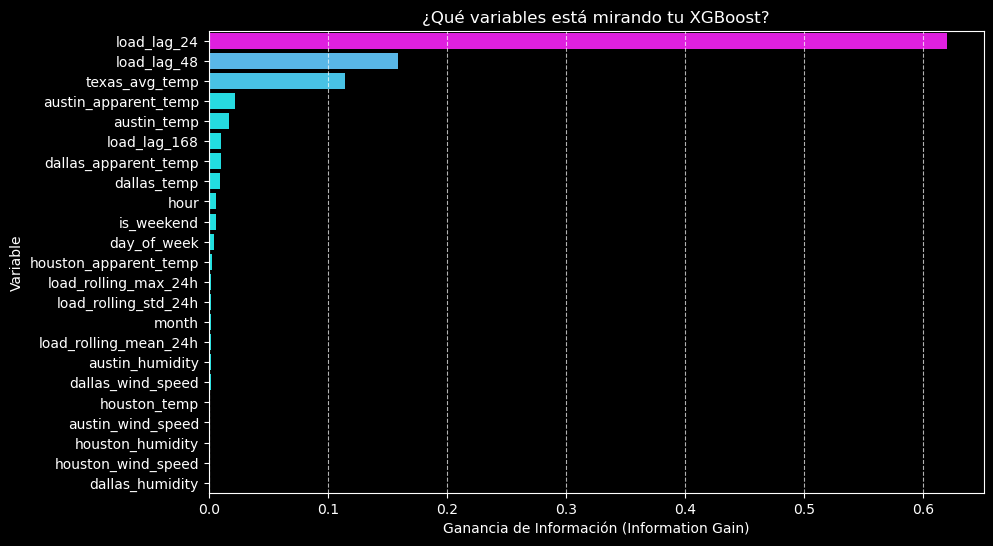

In [16]:
# Extraer la importancia de las variables
importancias = modelo_xgb.feature_importances_
variables = X_train.columns

# Crear un DataFrame para ordenar visualmente
df_importancia = pd.DataFrame({'Variable': variables, 'Importancia': importancias})
df_importancia = df_importancia.sort_values(by='Importancia', ascending=True)

# Graficar
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importancia', 
    y='Variable', 
    data=df_importancia.sort_values(by='Importancia', ascending=False), 
    palette='cool', 
    hue='Importancia', 
    dodge=False,
    legend=False
    )
plt.xlabel('Ganancia de Información (Information Gain)')
plt.title('¿Qué variables está mirando tu XGBoost?')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

**📌 Atención del modelo:** Como era de esperar en una serie temporal, los **retrasos de carga** (`load_lag_24`, `load_lag_168`) y las **variables de calendario** (`hour`) dominan la importancia: la mejor pista de la demanda de mañana es la demanda de ayer y la rutina horaria.

Para diagnosticar *dónde* falla el modelo, analizamos la distribución del error absoluto a lo largo de los meses del año.

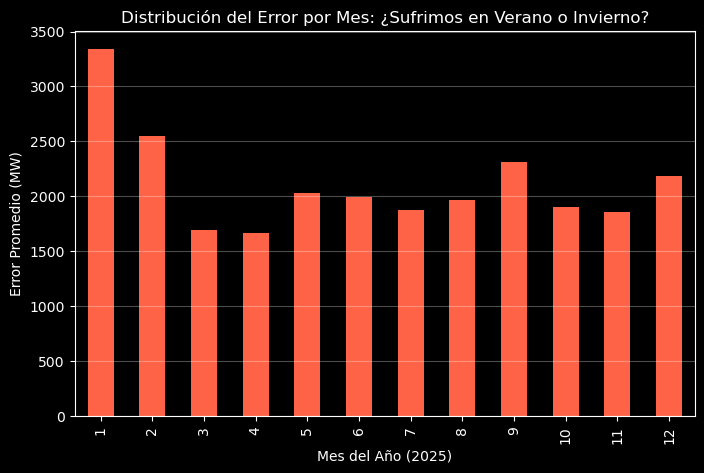

In [17]:
# Crear un DataFrame de análisis para el set de prueba
df_residuos = pd.DataFrame(index=X_test.index)
df_residuos['Real'] = y_test
df_residuos['Predicho'] = y_pred
df_residuos['Error_Absoluto'] = (df_residuos['Real'] - df_residuos['Predicho']).abs()

# Graficar el error absoluto promedio por mes para ver la estacionalidad del error
df_residuos.groupby(df_residuos.index.month)['Error_Absoluto'].mean().plot(
    kind='bar', color='tomato', figsize=(8, 5)
)
plt.xlabel('Mes del Año (2025)')
plt.ylabel('Error Promedio (MW)')
plt.title('Distribución del Error por Mes: ¿Sufrimos en Verano o Invierno?')
plt.grid(axis='y', alpha=0.3)
plt.show()

**📌 Estacionalidad del error:** El error no se distribuye de forma uniforme: se concentra en los **meses de estrés climático extremo** (picos de verano e invierno), cuando los frentes fríos súbitos y las olas de calor rompen la rutina. Este diagnóstico nos indica exactamente qué características debemos añadir para reforzar el modelo.

---

### 6. 🧪 Ingeniería de Características Avanzada

Atacamos directamente las debilidades detectadas en el baseline con tres nuevas familias de variables de dominio energético:

* 🎉 **Feriados federales (`is_holiday`):** Corrigen los errores en fechas como Navidad o Año Nuevo, cuando el consumo industrial se desploma pese a ser día laborable.
* 🌡️ **Delta térmico de 24h (`temp_delta_24h`):** Alerta al modelo sobre la **entrada súbita de frentes fríos**, capturando la *velocidad* del cambio de temperatura.
* 🔥❄️ **Grados-Día (HDD / CDD):** Técnica estándar en ingeniería energética que **linealiza la curva en U** midiendo cuánto se aleja la temperatura de la zona de confort (18.3 °C / 65 °F) por calor (CDD) o por frío (HDD).

In [18]:
# Asegúrate de trabajar sobre tu DataFrame unificado antes del split
df_enriched = df_cleaned.copy()

# =====================================================================
# 1. TRATAMIENTO DE DÍAS FERIADOS (Arregla el error de Enero/Diciembre)
# =====================================================================
# Vamos a mapear los feriados principales de EE.UU. que afectan a Texas
from pandas.tseries.holiday import USFederalHolidayCalendar
cal = USFederalHolidayCalendar()
# Generamos los feriados para nuestro rango completo de años
feriados = cal.holidays(start=df_enriched.index.min(), end=df_enriched.index.max())

# Creamos una columna booleana (1 si es feriado, 0 si no)
df_enriched['is_holiday'] = df_enriched.index.normalize().isin(feriados).astype(int)


# =====================================================================
# 2. DELTAS CLIMÁTICOS (Alerta de frentes fríos para el modelo)
# =====================================================================
# Calculamos cuánto cambió la temperatura respecto a ayer a la misma hora.
# Si el delta es muy negativo, el modelo sabrá que entró un frente frío súbito.
df_enriched['temp_delta_24h'] = df_enriched['texas_avg_temp'] - df_enriched['texas_avg_temp'].shift(24)


# =====================================================================
# 3. VARIABLES TÉRMICAS DE INGENIERÍA: HDD y CDD
# =====================================================================
# En ingeniería de energía, se usan los "Grados Día" para linealizar la curva en U.
# 18.3°C (65°F) es la base internacional de confort.
# CDD (Cooling Degree Days): Qué tanto calor hace por encima de la zona de confort.
# HDD (Heating Degree Days): Qué tanto frío hace por debajo de la zona de confort.
df_enriched['CDD'] = np.maximum(0, df_enriched['texas_avg_temp'] - 18.3)
df_enriched['HDD'] = np.maximum(0, 18.3 - df_enriched['texas_avg_temp'])

# Eliminamos los nuevos NaNs que se generaron en la primera fila del temp_delta
df_enriched = df_enriched.dropna()

Repetimos la **partición cronológica idéntica** (2022–2024 vs. 2025), ahora sobre el conjunto enriquecido de características, para medir el impacto de la nueva ingeniería de forma estrictamente comparable.

In [19]:
# 1. Definir la variable objetivo (Target) y las características (Features)
# Excluimos 'value' de las características porque es lo que queremos predecir
target_col = 'value'
feature_cols = [col for col in df_enriched.columns if col != target_col]

# 2. Separar en X (predictores) y y (target)
X = df_enriched[feature_cols]
y = df_enriched[target_col]

# 3. Realizar la partición temporal usando las fechas del DatetimeIndex
train_mask = X.index < '2025-01-01'
test_mask = X.index >= '2025-01-01'

X_train, y_train = X[train_mask], y[train_mask]
X_test, y_test = X[test_mask], y[test_mask]

print("=== Tamaño de las Matrices ===")
print(f"X_train (Entrenamiento): {X_train.shape} | Horas analizadas: {X_train.shape[0]}")
print(f"X_test (Validación/Prueba): {X_test.shape}  | Horas analizadas: {X_test.shape[0]}")
print(f"Número total de predictores (Features): {len(feature_cols)}")

=== Tamaño de las Matrices ===
X_train (Entrenamiento): (26112, 27) | Horas analizadas: 26112
X_test (Validación/Prueba): (8760, 27)  | Horas analizadas: 8760
Número total de predictores (Features): 27


El conjunto de predictores crece de 23 a **27 características**. Reentrenamos el mismo XGBoost con hiperparámetros idénticos: así, cualquier cambio en la métrica será atribuible **exclusivamente** a la nueva ingeniería de características y no al algoritmo.

In [20]:
# 1. Instanciar el modelo con hiperparámetros iniciales conservadores
# n_estimators: número de árboles, max_depth: profundidad para capturar interacciones
modelo_xgb = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1  # Usa todos los núcleos de tu procesador para ir a máxima velocidad
)

print("\n🏋️ Entrenando el modelo XGBoost con datos históricos (2022-2024)...")
modelo_xgb.fit(X_train, y_train)
print("¡Entrenamiento completado!")

# 2. Realizar las predicciones sobre el "futuro" (2025)
y_pred = modelo_xgb.predict(X_test)

# 3. Calcular las métricas de rendimiento
mae = metrics.mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(metrics.mean_squared_error(y_test, y_pred))
mape = metrics.mean_absolute_percentage_error(y_test, y_pred) * 100

print("\n================ METRICAS DE RENDIMIENTO (Año 2025) ================")
print(f"MAE:  {mae:.2f} MW  (Error promedio por hora)")
print(f"RMSE: {rmse:.2f} MW  (Penalización de desviaciones extremas)")
print(f"MAPE: {mape:.2f} %  (Error porcentual relativo)")
print("====================================================================")


🏋️ Entrenando el modelo XGBoost con datos históricos (2022-2024)...
¡Entrenamiento completado!

================ METRICAS DE RENDIMIENTO (Año 2025) ================
MAE:  1774.39 MW  (Error promedio por hora)
RMSE: 2283.85 MW  (Penalización de desviaciones extremas)
MAPE: 3.17 %  (Error porcentual relativo)


**📌 Impacto de la ingeniería avanzada:** El MAPE cae de **3.78% a 3.17%** (MAE ≈ 1,774 MW, RMSE ≈ 2,284 MW) — una mejora de **0.61 puntos porcentuales sin tocar el algoritmo**. Esto confirma empíricamente que las nuevas variables (deltas térmicos, HDD/CDD y feriados) aportaban señal predictiva genuina que faltaba en el baseline.

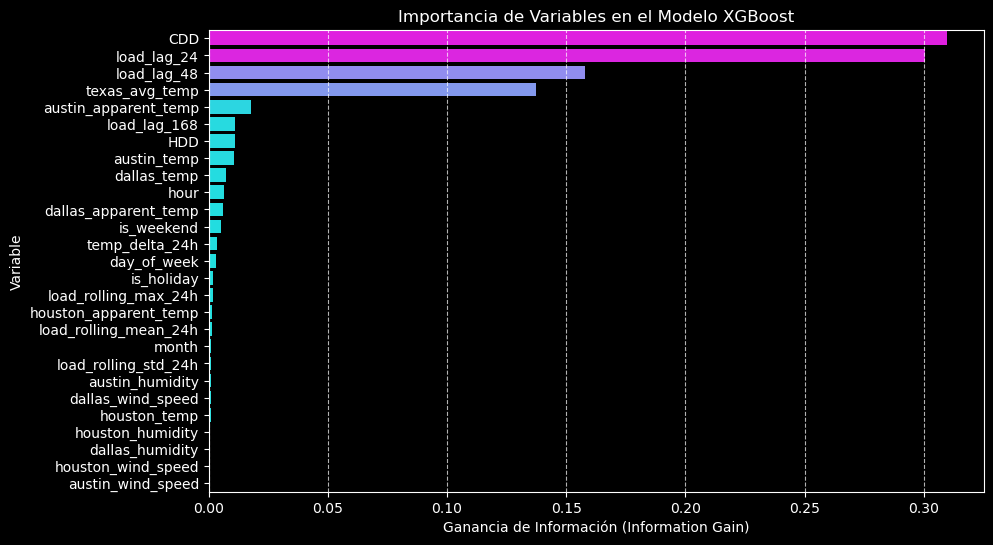

In [21]:
# Extraer la importancia de las variables
importancias = modelo_xgb.feature_importances_
variables = X_train.columns

# Crear un DataFrame para ordenar visualmente
df_importancia = pd.DataFrame({'Variable': variables, 'Importancia': importancias})
df_importancia = df_importancia.sort_values(by='Importancia', ascending=True)

# Graficar
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importancia', 
    y='Variable', 
    data=df_importancia.sort_values(by='Importancia', ascending=False), 
    palette='cool', 
    hue='Importancia', 
    dodge=False,
    legend=False
    )
plt.xlabel('Ganancia de Información (Information Gain)')
plt.title('Importancia de Variables en el Modelo XGBoost')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

Reexaminamos la importancia de características con el conjunto enriquecido para verificar si las nuevas variables ganan protagonismo, y repetimos el diagnóstico del error mensual.

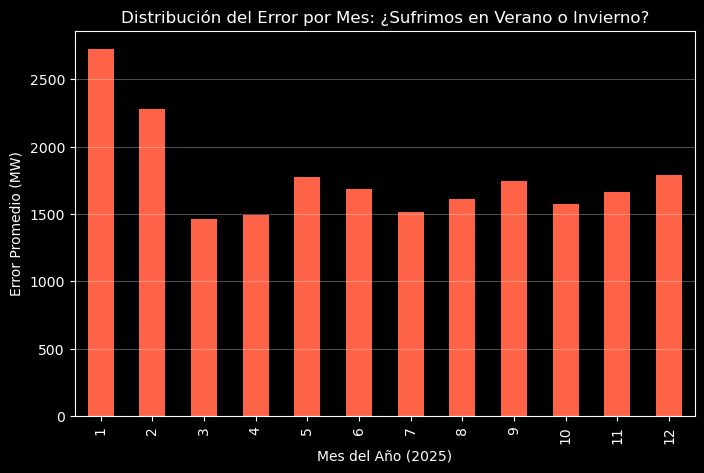

In [22]:
# Crear un DataFrame de análisis para el set de prueba
df_residuos = pd.DataFrame(index=X_test.index)
df_residuos['Real'] = y_test
df_residuos['Predicho'] = y_pred
df_residuos['Error_Absoluto'] = (df_residuos['Real'] - df_residuos['Predicho']).abs()

# Graficar el error absoluto promedio por mes para ver la estacionalidad del error
df_residuos.groupby(df_residuos.index.month)['Error_Absoluto'].mean().plot(
    kind='bar', color='tomato', figsize=(8, 5)
)
plt.xlabel('Mes del Año (2025)')
plt.ylabel('Error Promedio (MW)')
plt.title('Distribución del Error por Mes: ¿Sufrimos en Verano o Invierno?')
plt.grid(axis='y', alpha=0.3)
plt.show()

**📌 Validación de la mejora:** El error mensual se aplana respecto al baseline, confirmando que las variables de dominio energético suavizaron los picos de error en los meses críticos de verano e invierno.

---

### 7. 🔄 Validación Cruzada Temporal: XGBoost vs. LightGBM

Una única partición puede ser engañosa. Para medir la **estabilidad real** del modelo usamos `TimeSeriesSplit`, que genera ventanas de entrenamiento **expansivas**: cada pliegue entrena con todo el pasado disponible y valida sobre el bloque temporal inmediatamente siguiente, respetando siempre la flecha del tiempo. Evaluamos primero el XGBoost actual sobre 3 pliegues del bloque 2022–2024.

In [23]:
# 1. Configurar el validador temporal por ventanas expansivas
# Elegimos 3 splits para el bloque 2022-2024 (aproximadamente bloques progresivos de 9 meses)
tscv = TimeSeriesSplit(n_splits=3)

# 2. Reutilizamos el modelo XGBoost con los parámetros base
modelo_xgb_cv = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

# Listas para almacenar las métricas de cada pliegue
maes_cv = []
rmses_cv = []
mapes_cv = []

print("🚀 Iniciando Pipeline de Validación Cruzada Temporal (Datos 2022-2024)...")
print("-" * 70)

# 3. El bucle de validación cruzada
# .split() nos devuelve los índices posicionales para entrenamiento y validación interna
for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train)):
    
    # Separar los datos internamente usando ILOC (posiciones indexadas)
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    # Obtener los rangos de fechas para saber qué estamos evaluando en el log
    fecha_inicio_tr, fecha_fin_tr = X_tr.index.min(), X_tr.index.max()
    fecha_inicio_val, fecha_fin_val = X_val.index.min(), X_val.index.max()
    
    print(f"📂 [Fold {fold + 1}]")
    print(f"   Entrenamiento: {fecha_inicio_tr.strftime('%Y-%m')} a {fecha_fin_tr.strftime('%Y-%m')} ({len(X_tr)} horas)")
    print(f"   Validación:    {fecha_inicio_val.strftime('%Y-%m')} a {fecha_fin_val.strftime('%Y-%m')} ({len(X_val)} horas)")
    
    # Entrenar el modelo en este pliegue específico
    modelo_xgb_cv.fit(X_tr, y_tr)
    
    # Predecir el bloque de validación interna
    preds_val = modelo_xgb_cv.predict(X_val)
    
    # Calcular métricas del pliegue
    fold_mae = metrics.mean_absolute_error(y_val, preds_val)
    fold_rmse = np.sqrt(metrics.mean_squared_error(y_val, preds_val))
    fold_mape = metrics.mean_absolute_percentage_error(y_val, preds_val) * 100
    
    # Guardar resultados
    maes_cv.append(fold_mae)
    rmses_cv.append(fold_rmse)
    mapes_cv.append(fold_mape)
    
    print(f"   📉 Resultados -> MAE: {fold_mae:.2f} MW | RMSE: {fold_rmse:.2f} MW | MAPE: {fold_mape:.2f}%")
    print("-" * 70)

# 4. Consolidación y promedio de la validación cruzada
print("\n📊 =============== RESUMEN DE VALIDACIÓN CRUZADA ===============")
print(f"Promedio MAE:  {np.mean(maes_cv):.2f} MW (± {np.std(maes_cv):.2f})")
print(f"Promedio RMSE: {np.mean(rmses_cv):.2f} MW (± {np.std(rmses_cv):.2f})")
print(f"Promedio MAPE: {np.mean(mapes_cv):.2f} %  (± {np.std(mapes_cv):.2f})")
print("=================================================================")

🚀 Iniciando Pipeline de Validación Cruzada Temporal (Datos 2022-2024)...
----------------------------------------------------------------------
📂 [Fold 1]
   Entrenamiento: 2022-01 a 2022-10 (6528 horas)
   Validación:    2022-10 a 2023-07 (6528 horas)
   📉 Resultados -> MAE: 1629.02 MW | RMSE: 2170.29 MW | MAPE: 3.40%
----------------------------------------------------------------------
📂 [Fold 2]
   Entrenamiento: 2022-01 a 2023-07 (13056 horas)
   Validación:    2023-07 a 2024-04 (6528 horas)
   📉 Resultados -> MAE: 1693.18 MW | RMSE: 2237.45 MW | MAPE: 3.17%
----------------------------------------------------------------------
📂 [Fold 3]
   Entrenamiento: 2022-01 a 2024-04 (19584 horas)
   Validación:    2024-04 a 2024-12 (6528 horas)
   📉 Resultados -> MAE: 1894.19 MW | RMSE: 2344.32 MW | MAPE: 3.45%
----------------------------------------------------------------------

📊 =============== RESUMEN DE VALIDACIÓN CRUZADA ===============
Promedio MAE:  1738.79 MW (± 112.96)
Promedio

**📌 Robustez de XGBoost:** A lo largo de los 3 pliegues, el MAPE promedio es de **3.34% (± 0.12)**. La baja desviación estándar es excelente: indica que el modelo es **estable y no depende de un periodo afortunado**, generalizando de forma consistente a través de distintos regímenes estacionales.

Ahora sometemos a **LightGBM** —conocido por su velocidad y por su crecimiento de árboles orientado a hojas (*leaf-wise*)— exactamente al mismo protocolo de validación, para una comparación justa.

In [24]:
# 1. Instanciar LightGBM con parámetros análogos a tu XGBoost
# Nota: num_leaves controla la complejidad del árbol en LightGBM
modelo_lgb = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=6,
    num_leaves=31, 
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbose=-1 # Apaga los logs internos para ver una salida limpia
)

maes_lgb_cv = []
rmses_lgb_cv = []
mapes_lgb_cv = []

print("🚀 Iniciando Pipeline de Validación Cruzada Temporal con LightGBM...")
print("-" * 70)

# 2. Reutilizamos exactamente el mismo bucle de tu TimeSeriesSplit
for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train)):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    # Entrenar LightGBM
    modelo_lgb.fit(X_tr, y_tr)
    
    # Predecir
    preds_val = modelo_lgb.predict(X_val)
    
    # Métricas
    fold_mae = metrics.mean_absolute_error(y_val, preds_val)
    fold_rmse = np.sqrt(metrics.mean_squared_error(y_val, preds_val))
    fold_mape = metrics.mean_absolute_percentage_error(y_val, preds_val) * 100
    
    maes_lgb_cv.append(fold_mae)
    rmses_lgb_cv.append(fold_rmse)
    mapes_lgb_cv.append(fold_mape)
    
    print(f"📂 [Fold {fold + 1}] LGBM -> MAE: {fold_mae:.2f} MW | MAPE: {fold_mape:.2f}%")

print("\n📊 =============== COMPARATIVA DE RENDIMIENTO PROMEDIO ===============")
print(f"🤖 XGBoost  (Anterior) -> MAPE Promedio: 3.34 % (± 0.12)")
print(f"⚡ LightGBM (Nuevo)    -> MAPE Promedio: {np.mean(mapes_lgb_cv):.2f} % (± {np.std(mapes_lgb_cv):.2f})")
print("=======================================================================")

🚀 Iniciando Pipeline de Validación Cruzada Temporal con LightGBM...
----------------------------------------------------------------------
📂 [Fold 1] LGBM -> MAE: 1582.36 MW | MAPE: 3.31%
📂 [Fold 2] LGBM -> MAE: 1605.70 MW | MAPE: 3.05%
📂 [Fold 3] LGBM -> MAE: 1825.51 MW | MAPE: 3.32%

📊 =============== COMPARATIVA DE RENDIMIENTO PROMEDIO ===============
🤖 XGBoost  (Anterior) -> MAPE Promedio: 3.34 % (± 0.12)
⚡ LightGBM (Nuevo)    -> MAPE Promedio: 3.23 % (± 0.13)


**📌 LightGBM toma la delantera:** Con un MAPE promedio de **3.23% (± 0.13)**, LightGBM supera consistentemente a XGBoost (3.34%) bajo idéntica validación, y lo hace con un coste computacional menor. Lo coronamos como candidato a producción y procedemos a exprimir su rendimiento.

---

### 8. 🎯 Optimización de Hiperparámetros

Buscamos la configuración óptima de LightGBM con `RandomizedSearchCV`, explorando 15 combinaciones aleatorias sobre el espacio de hiperparámetros (número de hojas, profundidad, tasa de aprendizaje, submuestreo de filas y columnas), siempre amarrado a nuestro `TimeSeriesSplit` para no romper la integridad temporal de la validación.

In [25]:
# 1. Instanciamos el modelo base de LightGBM (sin fijar parámetros de estructura)
lgb_base = LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1)

# 2. Definimos el espacio de búsqueda (Rangos de hiperparámetros)
param_dist = {
    'n_estimators': [300, 500, 700],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'num_leaves': [15, 31, 63, 127],      # Controla la complejidad del árbol leaf-wise
    'max_depth': [4, 6, 8, -1],           # -1 significa sin límite de profundidad estricto
    'subsample': [0.7, 0.8, 0.9],         # Fracción de filas para cada árbol
    'colsample_bytree': [0.7, 0.8, 0.9]   # Fracción de columnas para cada árbol
}

# 3. Configurar la búsqueda aleatoria amarrada a tu TimeSeriesSplit
# n_iter=15 significa que probará 15 combinaciones al azar de forma inteligente
random_search = RandomizedSearchCV(
    estimator=lgb_base,
    param_distributions=param_dist,
    n_iter=15,
    cv=tscv,  # Tu TimeSeriesSplit de 3 folds
    scoring='neg_mean_absolute_percentage_error',  # Buscamos minimizar el MAPE
    random_state=42,
    n_jobs=-1
)

print("🏋️ Iniciando optimización de hiperparámetros (15 iteraciones x 3 folds)...")
random_search.fit(X_train, y_train)
print("¡Optimización completada!")

# 4. Extraer los mejores parámetros y el mejor score interno
mejores_params = random_search.best_params_
mejor_mape_interno = abs(random_search.best_score_) * 100

print("\n🏆 ================= MEJORES CONFIGURACIONES ENCONTRADAS =================")
print(f"MAPE Promedio en CV interno: {mejor_mape_interno:.2f} %")
print("Hiperparámetros óptimos:")
for param, val in mejores_params.items():
    print(f"   -> {param}: {val}")
print("==========================================================================")

🏋️ Iniciando optimización de hiperparámetros (15 iteraciones x 3 folds)...
¡Optimización completada!

🏆 ================= MEJORES CONFIGURACIONES ENCONTRADAS =================
MAPE Promedio en CV interno: 3.21 %
Hiperparámetros óptimos:
   -> subsample: 0.8
   -> num_leaves: 63
   -> n_estimators: 500
   -> max_depth: 4
   -> learning_rate: 0.05
   -> colsample_bytree: 0.9


**📌 Configuración óptima:** La búsqueda converge en una combinación equilibrada (`num_leaves=63`, `max_depth=4`, `learning_rate=0.05`, `n_estimators=500`, `subsample=0.8`, `colsample_bytree=0.9`) con un MAPE interno de 3.21%. La profundidad moderada (4) combinada con 63 hojas favorece la **generalización por encima del sobreajuste**.

Entrenamos el modelo final con estos hiperparámetros sobre todo el bloque histórico (2022–2024) y lo evaluamos sobre el año de prueba ciego 2025.

In [26]:
# 1. Instanciar el modelo final con los hiperparámetros óptimos encontrados

modelo_final_lgb = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.9,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

print("🏋️ Entrenando el modelo LightGBM Optimizado en todo el bloque histórico (2022-2024)...")
modelo_final_lgb.fit(X_train, y_train)
print("¡Entrenamiento final completado!")

# 2. Inferencia en vivo sobre el año de prueba protegido (2025)
y_pred_final = modelo_final_lgb.predict(X_test)

# 3. Calcular métricas finales
mae_final = metrics.mean_absolute_error(y_test, y_pred_final)
rmse_final = np.sqrt(metrics.mean_squared_error(y_test, y_pred_final))
mape_final = metrics.mean_absolute_percentage_error(y_test, y_pred_final) * 100

print("\n🏆 ================= METRICAS DE EVALUACIÓN FINAL (Año 2025) ================")
print(f"🥇 MAE:  {mae_final:.2f} MW  (Error promedio por hora)")
print(f"⚡ RMSE: {rmse_final:.2f} MW  (Penalización de extremos)")
print(f"🎯 MAPE: {mape_final:.2f} %  (Precisión porcentual final)")
print("==============================================================================")

# 4. Comparativa histórica del proyecto
print("\n📈 Evolución del proyecto (Progreso en Test 2025):")
print(f"   1. Baseline Inicial (XGBoost sin features):   3.78 %")
print(f"   2. Modelo con Feature Engineering Avanzado:  3.17 %")
print(f"   3. Modelo Optimizado Final (LightGBM Tuning): {mape_final:.2f} %")

🏋️ Entrenando el modelo LightGBM Optimizado en todo el bloque histórico (2022-2024)...
¡Entrenamiento final completado!

🏆 ================= METRICAS DE EVALUACIÓN FINAL (Año 2025) ================
🥇 MAE:  1734.57 MW  (Error promedio por hora)
⚡ RMSE: 2224.18 MW  (Penalización de extremos)
🎯 MAPE: 3.11 %  (Precisión porcentual final)

📈 Evolución del proyecto (Progreso en Test 2025):
   1. Baseline Inicial (XGBoost sin features):   3.78 %
   2. Modelo con Feature Engineering Avanzado:  3.17 %
   3. Modelo Optimizado Final (LightGBM Tuning): 3.11 %


**📌 Rendimiento final:** El LightGBM optimizado alcanza un **MAPE de 3.11%** (MAE ≈ 1,735 MW, RMSE ≈ 2,224 MW) sobre 2025, el mejor resultado del proyecto. La evolución completa resume el valor incremental de cada fase:

| Fase | MAPE (Test 2025) |
|---|---|
| Baseline XGBoost | 3.78% |
| + Ingeniería Avanzada | 3.17% |
| 🥇 LightGBM Optimizado | **3.11%** |

---

### 9. 🚀 Modelo de Producción y Serialización

Validada la arquitectura, entrenamos el **modelo de producción definitivo** usando el **100% de los datos disponibles (2022–2025)**. En producción no desperdiciamos información: el año 2025, antes reservado para prueba, ahora se incorpora al entrenamiento para que el modelo capture también los patrones más recientes antes de su despliegue.

In [27]:
print("🏋️ Entrenando el MODELO DE PRODUCCIÓN FINAL con el 100% de los datos (2022-2025)...")

# 1. Instanciamos el modelo con los hiperparámetros óptimos idénticos
modelo_produccion = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.9,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

# 2. Ajustamos con X e y COMPLETOS (sin divisiones)
modelo_produccion.fit(X, y)
print("¡Modelo de producción completamente entrenado!")

# 3. Serialización definitiva para tu App de Streamlit
os.makedirs('../data', exist_ok=True)
modelo_produccion.booster_.save_model('../data/modelo_final_ercot_lgb.json')
print("\n[OK] '../data/modelo_final_ercot_lgb.json' actualizado y listo para producción.")

🏋️ Entrenando el MODELO DE PRODUCCIÓN FINAL con el 100% de los datos (2022-2025)...
¡Modelo de producción completamente entrenado!

[OK] '../data/modelo_final_ercot_lgb.json' actualizado y listo para producción.


El modelo entrenado se serializa en formato JSON (`modelo_final_ercot_lgb.json`) mediante el `Booster` nativo de LightGBM. Este es precisamente el artefacto que carga el dashboard `app.py` para realizar las inferencias en vivo. Finalmente, inspeccionamos la importancia de características del modelo de producción.

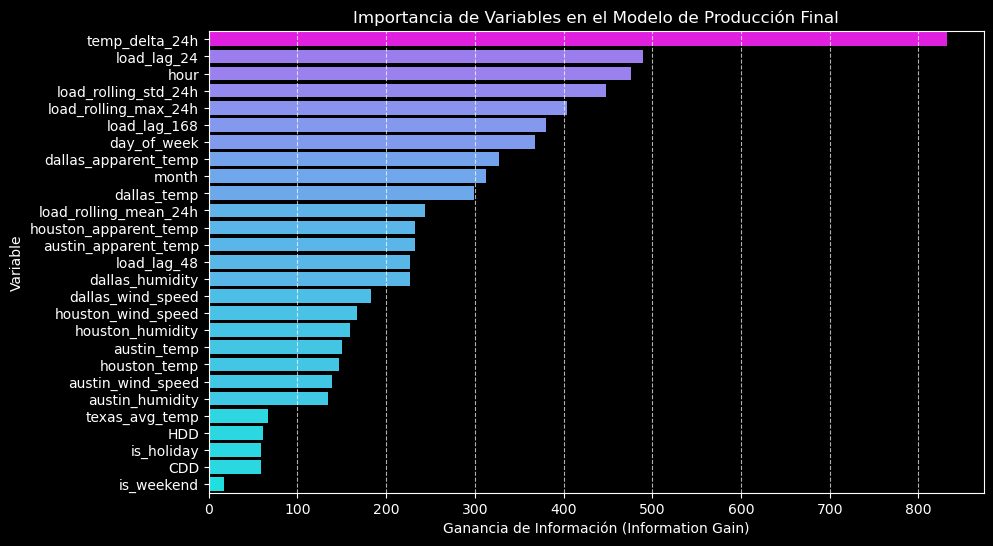

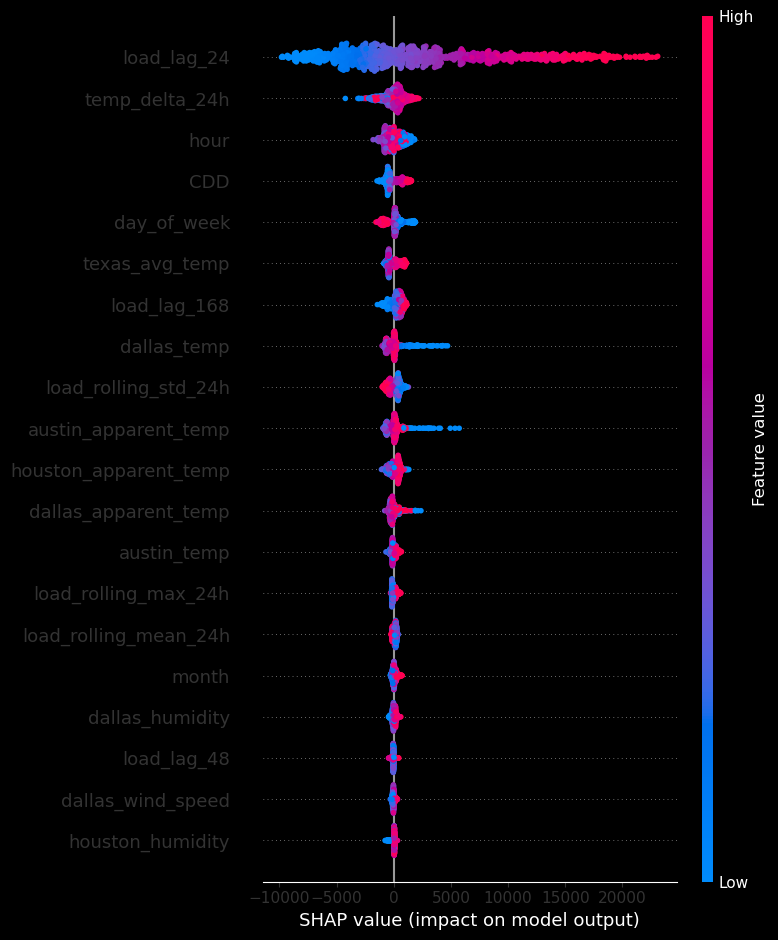

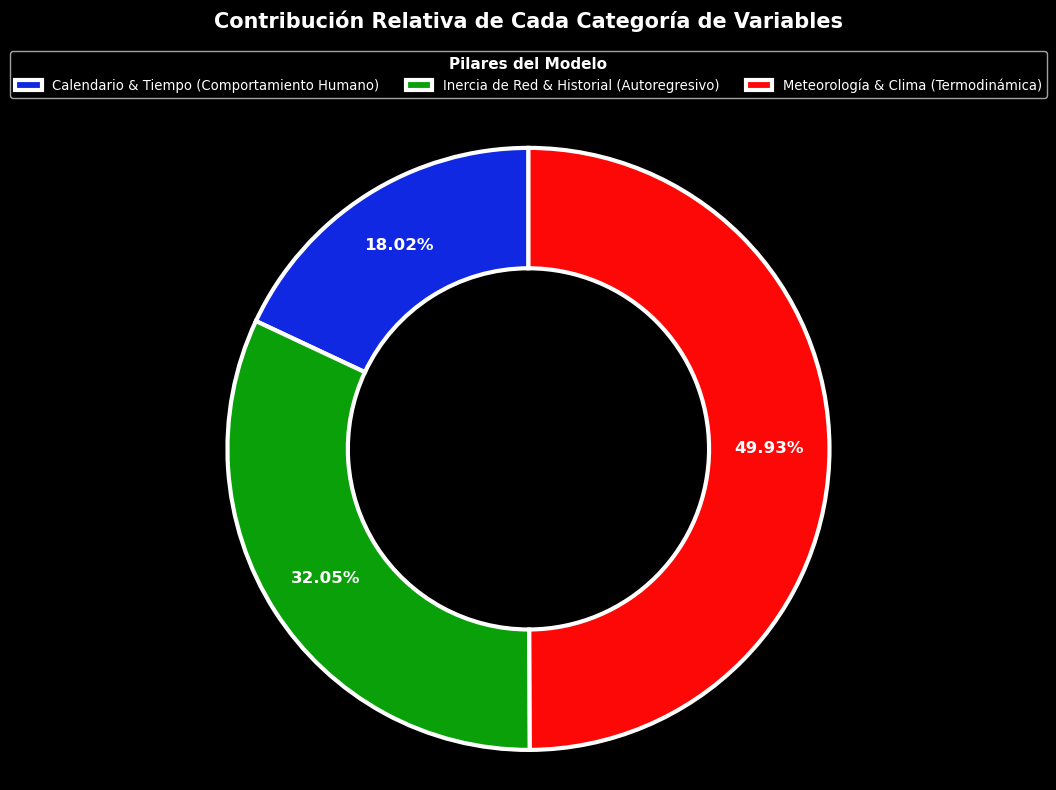

In [28]:
# Extraer la importancia de las variables
importancias = modelo_produccion.feature_importances_
variables = X.columns

# Crear un DataFrame para ordenar visualmente
df_importancia = pd.DataFrame({'Variable': variables, 'Importancia': importancias})
df_importancia = df_importancia.sort_values(by='Importancia', ascending=True)

# Graficar
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importancia', 
    y='Variable', 
    data=df_importancia.sort_values(by='Importancia', ascending=False), 
    palette='cool', 
    hue='Importancia', 
    dodge=False,
    legend=False
    )
plt.xlabel('Ganancia de Información (Information Gain)')
plt.title('Importancia de Variables en el Modelo de Producción Final')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

explainer = shap.TreeExplainer(modelo_produccion)
shap_values = explainer.shap_values(X_test.sample(1000, random_state=42))  # Tomamos una muestra para acelerar el cálculo
# Graficar el resumen de SHAP para las 20 variables más importantes
shap.summary_plot(shap_values, X_test.sample(1000, random_state=42))

def categorizar_variable(var):
    if any(x in var for x in ['temp', 'humidity', 'wind', 'CDD', 'HDD', 'delta_24h']):
        return 'Meteorología & Clima (Termodinámica)'
    elif any(x in var for x in ['load_', 'lag_']):
        return 'Inercia de Red & Historial (Autoregresivo)'
    else:
        return 'Calendario & Tiempo (Comportamiento Humano)'
        
df_importancia['Categoría'] = df_importancia['Variable'].apply(categorizar_variable)
df_pie = df_importancia.groupby('Categoría')['Importancia'].sum().reset_index()

# 2. Configuración del lienzo (Damos un poco más de altura para el aire superior)
fig, ax = plt.subplots(figsize=(10, 8))

# 3. Creación del Gráfico de Dona
wedges, texts, autotexts = ax.pie(
    df_pie['Importancia'], 
    autopct='%1.2f%%', 
    startangle=90, 
    colors=["#1028e2", "#0aa00a", "#fd0707"],
    pctdistance=0.80,
    wedgeprops=dict(width=0.4, edgecolor='white', linewidth=3) 
)

# 4. Estilización de los porcentajes internos
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(12)
    autotext.set_weight('bold')

# 5. 🛠️ Configuración de la Leyenda Horizontal ARRIBA
ax.legend(
    wedges, 
    df_pie['Categoría'],
    title="Pilares del Modelo",
    title_fontproperties={'weight': 'bold', 'size': 11},
    loc="lower center",          # El punto de anclaje de la caja es su base central
    bbox_to_anchor=(0.5, 1.02),  # (x=centro, y=justo arriba del límite del gráfico)
    ncol=3,                      # 🌟 Fuerza el formato horizontal en 3 columnas
    fontsize=9.5,
    frameon=True                 # Caja sutil para delimitar las opciones
)

# 6. 🛠️ Título Principal (Aumentamos 'pad' a 65 para dar espacio a la leyenda)
plt.title('Contribución Relativa de Cada Categoría de Variables', fontsize=15, weight='bold', pad=65)
ax.axis('equal')  
plt.tight_layout()

plt.show()

**📌 ¿En qué se fija el modelo de producción?**

 El ranking de importancia confirma la jerarquía de drivers que alimenta el dashboard: el **delta térmico de 24h** (`temp_delta_24h`), el **historial de carga reciente** (`load_lag_24`, `load_lag_168`) y la **hora del día** concentran la mayor capacidad predictiva.

 Pero al agrupar las características por categorías ('Meteorología & Clima', 'Inercia de Red & Historial' y 'Calendario & Tiempo'), se observa que:

- **50%** de la importancia total proviene de las variables de **Meteorología & Clima**
- **32%** de las variables de **Inercia de Red & Historial**
- **18%** de las variables de **Calendario & Tiempo**

Esto confirma que la demanda eléctrica de Texas es, en esencia, una función de la **termodinámica** del clima mas la **inercia de la red**, ajustado por **Calendario & Tiempo**.

---

## 10. 🏁 Conclusiones y Recomendación Final

Tras la unificación de las fuentes EIA y Open-Meteo, la limpieza, el EDA, la ingeniería de características y el modelado comparativo bajo validación temporal rigurosa, llegamos a las siguientes conclusiones:

**Hallazgos Técnicos:**

* **La demanda eléctrica es termodinámica + inercia:** El EDA reveló la característica **curva en U** (frío y calor disparan el consumo) y el modelado confirmó que los drivers dominantes son el **delta térmico** y el **historial de carga reciente**. La red "recuerda" su comportamiento de ayer y reacciona a los frentes climáticos.

* **La ingeniería de características superó al algoritmo:** El mayor salto de precisión (de 3.78% a 3.17% de MAPE) provino de **añadir variables de dominio energético** (HDD/CDD, deltas térmicos, feriados), no de cambiar de modelo. La migración a LightGBM y el *tuning* aportaron la mejora fina final hasta **3.11%**.

* **Validación a prueba de fugas:** La partición estrictamente cronológica y el uso de `TimeSeriesSplit` con `shift(24)` en todas las variables históricas garantizan que las métricas reflejen el rendimiento real en producción, sin fuga de información del futuro (*data leakage*).

* **Evolución del rendimiento:**

    | Fase | MAPE (Test 2025) | MAE (MW) | RMSE (MW) |
    |---|---|---|---|
    | Baseline XGBoost | 3.78% | ~2,112 | ~2,655 |
    | + Ingeniería Avanzada | 3.17% | ~1,774 | ~2,284 |
    | 🥇 **LightGBM Optimizado** | **3.11%** | **~1,735** | **~2,224** |

**Recomendación Final:**

* **Modelo seleccionado: LightGBM optimizado**, por su combinación de precisión (MAPE 3.11%), estabilidad temporal (± 0.13 en validación cruzada) y eficiencia computacional.

* **Impacto operativo:** Con un error medio de ~1,735 MW sobre una demanda media cercana a 55,000 MW (con picos que superan los 75,000 MW), el modelo ofrece pronósticos suficientemente precisos para apoyar la **planificación del despacho de generación a 24 horas** y la **anticipación de picos de estrés en la red**. Es el motor que alimenta el dashboard ejecutivo `app.py`, donde se sirve en tiempo real con una arquitectura de APIs redundante.

* **Líneas de trabajo futuras:**
    1. Incorporar pronósticos meteorológicos probabilísticos para cuantificar la incertidumbre del *forecast*.
    2. Modelar explícitamente los picos extremos (regresión por cuantiles), dado que el RMSE > MAE señala que ahí reside el error residual.
    3. Establecer un reentrenamiento automático periódico para combatir el *data drift* y mantener la precisión en el tiempo.